## Librerías utilizadas

- **pandas (`pd`)**  
  Manipulación de datos en DataFrames.  
  Ej: `read_csv()`, `groupby()`, `merge()`

- **numpy (`np`)**  
  Cálculo numérico y arreglos.  
  Ej: `mean()`, `std()`, `where()`

- **pathlib (`Path`)**  
  Manejo de rutas de archivos de forma flexible.  
  Ej: `Path("data/archivo.csv")`

- **matplotlib (`plt`)**  
  Visualización básica.  
  Ej: `plot()`, `hist()`, `show()`

- **seaborn (`sns`)**  
  Visualización estadística más avanzada.  
  Ej: `lineplot()`, `heatmap()`, `boxplot()`

- **plothy (`px`)**  
  Visualización interactiva y dinámica, ideal para dashboards y exploración de datos en la web.
  Ej: px.scatter(), px.bar(), px.choropleth()

Estas librerías permiten manipular datos, manejar archivos y generar visualizaciones para el análisis.

In [55]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Importación de la data

##  Fuente de datos

La base de datos utilizada proviene del portal de microdatos del INEI:  
🔗 https://proyectos.inei.gob.pe/microdatos/

Se emplea la **Encuesta Demográfica y de Salud Familiar (ENDES)** del año **2024**, correspondiente al último periodo disponible con información publicada.

ENDES es una de las principales encuestas nacionales en Perú, utilizada para analizar temas de salud, demografía y condiciones socioeconómicas de los hogares :contentReference[oaicite:0]{index=0}.

Se utilizó el módulo 1629 – Características del Hogar

# 1629 Características del hogar


El módulo **1629 – Características del Hogar** contiene cuatro datasets principales:

- **RECH0_2024.csv**
- **RECH1_2024.csv**
- **RECH4_2024.csv**
- **RECHM_2024.csv**

Cada archivo recoge información distinta asociada al hogar, sus miembros o características específicas de la vivienda.

### Dataset seleccionado: `RECH0_2024.csv`

Para este análisis se utiliza el dataset **RECH0_2024.csv**, porque contiene información general del hogar y de la vivienda, como características físicas, acceso a servicios básicos y condiciones del entorno habitacional.

In [3]:
# RECH0 es una base a nivel hogar
# RECH1 Es la base a nivel persona del hogar.
# RECH4 Está a nivel persona
# RECHM mortalidad
# Para nuestros fines nos conviene usar RECH0 

In [4]:
base = Path("../data/demografica_salud_ENDES")

ruta_rech0 = base / "1629" / "RECH0_2024.csv"
ruta_rech1 = base / "1629" / "RECH1_2024.csv"

rech0 = pd.read_csv(ruta_rech0, dtype=str)
rech1 = pd.read_csv(ruta_rech1, dtype=str)

In [6]:
rech0
# Si bien los nombres de las variables no son muy intuitivos, podemos usar el diccionario de datos

,ID1,HHID,HV000,HV001,HV002,HV002A,HV003,HV004,HV007,HV008,...,HV043,HV044,UBIGEO,HV022,HV005,CODCCPP,NOMCCPP,LATITUDY,LONGITUDX,NCONGLOME1
0,2024,325502001,PE6,3255,20,1,0,3255,2024,1493,...,0,1,010101,2,0,0001,CHACHAPOYAS,-6.2258317,-77.8613021,07076
1,2024,325503101,PE6,3255,31,1,2,3255,2024,1493,...,0,1,010101,2,74497,0001,CHACHAPOYAS,-6.2258317,-77.8613021,07076
2,2024,325503901,PE6,3255,39,1,1,3255,2024,1493,...,0,1,010101,2,607697,0001,CHACHAPOYAS,-6.2258317,-77.8613021,07076
3,2024,325504001,PE6,3255,40,1,1,3255,2024,1493,...,0,1,010101,2,607697,0001,CHACHAPOYAS,-6.2258317,-77.8613021,07076
4,2024,325504701,PE6,3255,47,1,2,3255,2024,1493,...,0,1,010101,2,74497,0001,CHACHAPOYAS,-6.2258317,-77.8613021,07076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37385,2024,705704301,PE6,7057,43,1,1,7057,2024,1500,...,0,1,110101,100,251377,0001,ICA,-14.03525917,-75.737065,3426301
37386,2024,705705001,PE6,7057,50,1,2,7057,2024,1500,...,0,1,110101,100,251377,0001,ICA,-14.03525917,-75.737065,3426301
37387,2024,705706501,PE6,7057,65,1,2,7057,2024,1500,...,0,1,110101,100,251377,0001,ICA,-14.03525917,-75.737065,3426301
37388,2024,705707301,PE6,7057,73,1,0,7057,2024,1500,...,0,1,110101,100,0,0001,ICA,-14.03525917,-75.737065,3426301


In [7]:
# Algunas validaciones
rech0['UBIGEO'] = rech0['UBIGEO'].astype(str).str.zfill(6)
rech0["ID1"] = rech0["ID1"].astype(int)


Por el diccionario de datos, vemos que no todas las variables son útiles para el análisis, dado que algunas son propias de la encuesta (por ejemplo: número de encuestador) por lo tanto nos quedaremos solo con aquellas variables que podamos graficar para fines de este curso

In [ ]:
# Nos quedaremos solo con las vairables
cols_keep = [
    # Identificación
    "ID1",        # Año
    "HHID",       # Identificación del hogar

    # Ubicación geográfica
    "HV024",      # Región / departamento
    "HV025",      # Área de residencia: urbano/rural
    "HV026",      # Lugar de residencia
    "UBIGEO",     # Código de ubicación geográfica
    "CODCCPP",    # Código de centro poblado
    "NOMCCPP",    # Nombre del centro poblado
    "LONGITUDX",  # Longitud
    "LATITUDY",   # Latitud

    # Composición del hogar
    "HV009",      # Total de personas en el hogar
    "HV010",      # Mujeres elegibles
    "HV011",      # Hombres elegibles
    "HV012",      # Miembros residentes habituales
    "HV013",      # Personas que durmieron la noche anterior
    "HV014",      # Niños menores de 5 años

    # Características de muestreo / contexto
    "HV021",      # Unidad de muestreo primario
    "HV022",      # Estrato
    "HV023",      # Dominio
    "HV040",      # Altitud del conglomerado

    # Variables útiles para filtros o ponderación
    "HV015",      # Resultado de entrevista
    "HV017",      # Número de visitas
    "HV005"       # Factor de ponderación
]


rech0= rech0[cols_keep].copy()

In [9]:
rech0

,ID1,HHID,HV024,HV025,HV026,UBIGEO,CODCCPP,NOMCCPP,LONGITUDX,LATITUDY,...,HV012,HV013,HV014,HV021,HV022,HV023,HV040,HV015,HV017,HV005
0,2024,325502001,1,1,1,010101,0001,CHACHAPOYAS,-77.8613021,-6.2258317,...,0,0,0,3255,2,1,2293,3,4,0
1,2024,325503101,1,1,1,010101,0001,CHACHAPOYAS,-77.8613021,-6.2258317,...,4,4,1,3255,2,1,2293,1,1,74497
2,2024,325503901,1,1,1,010101,0001,CHACHAPOYAS,-77.8613021,-6.2258317,...,2,2,0,3255,2,1,2293,1,1,607697
3,2024,325504001,1,1,1,010101,0001,CHACHAPOYAS,-77.8613021,-6.2258317,...,1,1,0,3255,2,1,2293,1,1,607697
4,2024,325504701,1,1,1,010101,0001,CHACHAPOYAS,-77.8613021,-6.2258317,...,4,4,1,3255,2,1,2293,1,1,74497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37385,2024,705704301,11,1,1,110101,0001,ICA,-75.737065,-14.03525917,...,4,4,1,7057,100,11,442,1,1,251377
37386,2024,705705001,11,1,1,110101,0001,ICA,-75.737065,-14.03525917,...,10,10,2,7057,100,11,442,1,1,251377
37387,2024,705706501,11,1,1,110101,0001,ICA,-75.737065,-14.03525917,...,4,4,1,7057,100,11,442,1,1,251377
37388,2024,705707301,11,1,1,110101,0001,ICA,-75.737065,-14.03525917,...,0,0,0,7057,100,11,442,3,5,0


# Separamos nuestras variables en categóricas y numéricas

In [10]:
rech0.dtypes

ID1           int32
HHID         object
HV024        object
HV025        object
HV026        object
UBIGEO       object
CODCCPP      object
NOMCCPP      object
LONGITUDX    object
LATITUDY     object
HV009        object
HV010        object
HV011        object
HV012        object
HV013        object
HV014        object
HV021        object
HV022        object
HV023        object
HV040        object
HV015        object
HV017        object
HV005        object
dtype: object

Nos damos cuenta que al inicio casi todas las variables son del tipo objeto, debemos clasificarlas

In [ ]:
# Categóricas (IDs, regiones, clasificaciones)
cat = [
    "ID1",        # Año (discreto, mejor como categoría)
    "HHID",       # ID hogar
    "HV024",      # Región
    "HV025",      # Urbano / rural
    "HV026",      # Tipo de lugar
    "UBIGEO",     # Ubicación geográfica
    "CODCCPP",    # Centro poblado
    "NOMCCPP",    # Nombre (texto)
    "HV021",      # Conglomerado
    "HV022",      # Estrato
    "HV023",      # Dominio
    "HV015"       # Resultado entrevista
]

# Numéricas (cantidades, conteos, continuas)
num = [
    "LONGITUDX",  # Longitud
    "LATITUDY",   # Latitud
    "HV009",      # Total personas
    "HV010",      # Mujeres elegibles
    "HV011",      # Hombres elegibles
    "HV012",      # Miembros de jure
    "HV013",      # Miembros de facto
    "HV014",      # Niños <5
    "HV017",      # Número de visitas
    "HV040",      # Altitud
    "HV005"       # Peso muestral
]

rech0[cat] = rech0[cat].astype("category")
rech0[num] = rech0[num].apply(pd.to_numeric, errors="coerce")




In [16]:
# ver el tipo de dato
rech0.dtypes

ID1          category
HHID         category
HV024        category
HV025        category
HV026        category
UBIGEO       category
CODCCPP      category
NOMCCPP      category
LONGITUDX     float64
LATITUDY      float64
HV009           int64
HV010           int64
HV011           int64
HV012           int64
HV013           int64
HV014           int64
HV021        category
HV022        category
HV023        category
HV040           int64
HV015        category
HV017           int64
HV005           int64
dtype: object

# GRÁFICOS

In [17]:
rech0

,ID1,HHID,HV024,HV025,HV026,UBIGEO,CODCCPP,NOMCCPP,LONGITUDX,LATITUDY,...,HV012,HV013,HV014,HV021,HV022,HV023,HV040,HV015,HV017,HV005
0,2024,325502001,1,1,1,010101,0001,CHACHAPOYAS,-77.861302,-6.225832,...,0,0,0,3255,2,1,2293,3,4,0
1,2024,325503101,1,1,1,010101,0001,CHACHAPOYAS,-77.861302,-6.225832,...,4,4,1,3255,2,1,2293,1,1,74497
2,2024,325503901,1,1,1,010101,0001,CHACHAPOYAS,-77.861302,-6.225832,...,2,2,0,3255,2,1,2293,1,1,607697
3,2024,325504001,1,1,1,010101,0001,CHACHAPOYAS,-77.861302,-6.225832,...,1,1,0,3255,2,1,2293,1,1,607697
4,2024,325504701,1,1,1,010101,0001,CHACHAPOYAS,-77.861302,-6.225832,...,4,4,1,3255,2,1,2293,1,1,74497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37385,2024,705704301,11,1,1,110101,0001,ICA,-75.737065,-14.035259,...,4,4,1,7057,100,11,442,1,1,251377
37386,2024,705705001,11,1,1,110101,0001,ICA,-75.737065,-14.035259,...,10,10,2,7057,100,11,442,1,1,251377
37387,2024,705706501,11,1,1,110101,0001,ICA,-75.737065,-14.035259,...,4,4,1,7057,100,11,442,1,1,251377
37388,2024,705707301,11,1,1,110101,0001,ICA,-75.737065,-14.035259,...,0,0,0,7057,100,11,442,3,5,0


# Gráfico de barras

In [18]:
# Diccionario de regiones
region_map = {
    1: "Amazonas",
    2: "Ancash",
    3: "Apurimac",
    4: "Arequipa",
    5: "Ayacucho",
    6: "Cajamarca",
    7: "Callao",
    8: "Cusco",
    9: "Huancavelica",
    10: "Huanuco",
    11: "Ica",
    12: "Junin",
    13: "La Libertad",
    14: "Lambayeque",
    15: "Lima",
    16: "Loreto",
    17: "Madre de Dios",
    18: "Moquegua",
    19: "Pasco",
    20: "Piura",
    21: "Puno",
    22: "San Martin",
    23: "Tacna",
    24: "Tumbes",
    25: "Ucayali"
}

# Crear columna con nombre de región
rech0["region"] = rech0["HV024"].astype(int).map(region_map)

In [21]:
rech0["region"].unique() # Ver valores únicos por columna ["region"]

array(['Amazonas', 'Ancash', 'Apurimac', 'Arequipa', 'Ayacucho',
       'Cajamarca', 'Callao', 'Cusco', 'Huancavelica', 'Huanuco', 'Ica',
       'Junin', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto',
       'Madre de Dios', 'Moquegua', 'Pasco', 'Piura', 'Puno',
       'San Martin', 'Tacna', 'Tumbes', 'Ucayali'], dtype=object)

In [23]:
# Total de personas entrevistadas por región, lo podemos ver AGRUPANDO POR REGIÓN Y SUMANDO EL TOTAL DE PERSONAS (HV009)
personas_region = (
    rech0.groupby("region", as_index=False)["HV009"]
    .sum()
    .rename(columns={"HV009": "total_personas"})
    .sort_values("total_personas", ascending=False)
)

In [24]:
# Ver el cuadro AGRUPADO que acabamos de hacer
personas_region

,region,total_personas
14,Lima,16856
15,Loreto,5998
19,Piura,5531
24,Ucayali,5519
4,Ayacucho,5451
9,Huanuco,5438
0,Amazonas,5386
12,La Libertad,5376
10,Ica,5322
13,Lambayeque,5234


C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13208\1609956867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=personas_region, x="region", y="total_personas", palette="viridis")


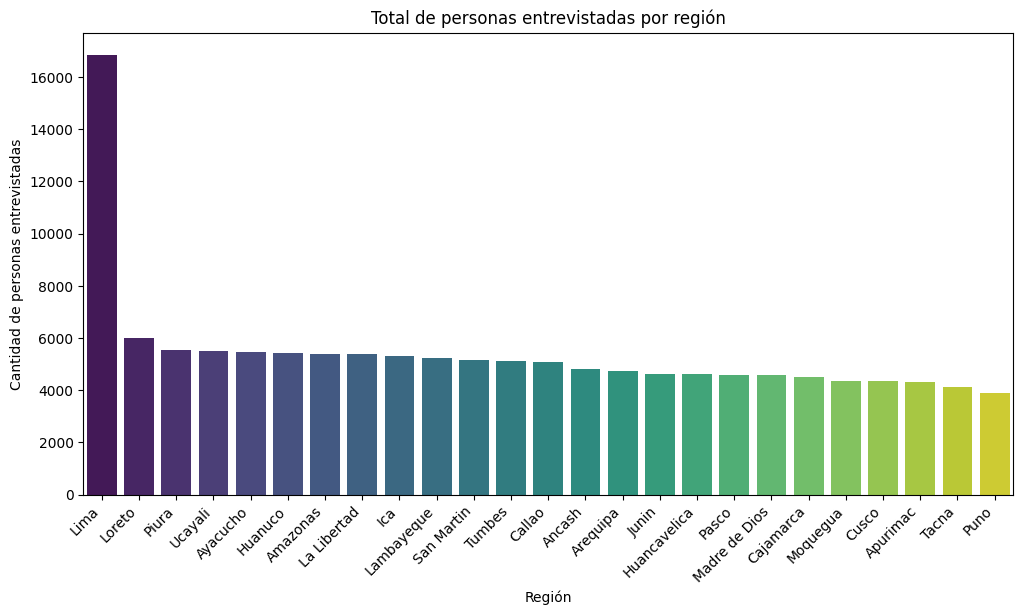

In [25]:
# Haceemos un gráfico de barras para visualizar personas_region
plt.figure(figsize=(12, 6))
sns.barplot(data=personas_region, x="region", y="total_personas", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Total de personas entrevistadas por región")
plt.xlabel("Región")
plt.ylabel("Cantidad de personas entrevistadas")
plt.show()

_Comentario: La mayor concentración de muestra está en Lima, porque concentra gran cantidad de personas o porque es más accesible acceder a ellos, mientras que en las otras regiones no vemos mucha diferencia en cuanto al número de personas entrevistadas_

# GRÁFICO DE LÍNEAS

Dado que nuestra data es de un solo año (2024) y no tenemos alguna otra variable de temporalidad, no es conveniente hacer un gráfico de líneas, pero para fines de este curso, crearemos una base de datos que se adapte a este caso

In [30]:
# Fechas mensuales de 1 año
fechas = pd.date_range(start="2024-01-01", end="2024-12-01", freq="MS")

# Crear base simulada
np.random.seed(30)

base_lineas = pd.DataFrame({
    "fecha": fechas,
    "total_personas": np.random.randint(800, 2000, size=len(fechas)),
    "total_hogares": np.random.randint(200, 600, size=len(fechas))
})


base_lineas

,fecha,total_personas,total_hogares
0,2024-01-01,1221,363
1,2024-02-01,1741,218
2,2024-03-01,1300,218
3,2024-04-01,1964,316
4,2024-05-01,1719,558
5,2024-06-01,1698,590
6,2024-07-01,1563,262
7,2024-08-01,1969,483
8,2024-09-01,1955,246
9,2024-10-01,1225,373


C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13208\2184607868.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=base_lineas, x="fecha", y="total_personas", palette="viridis")


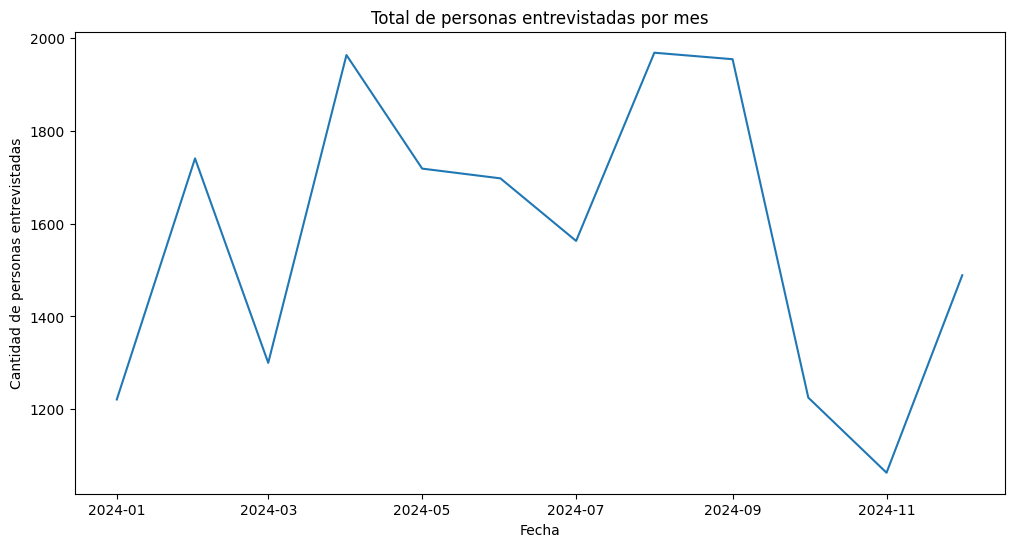

In [31]:
# Hacer un gráfico de líneas para base_lineas
plt.figure(figsize=(12, 6))
sns.lineplot(data=base_lineas, x="fecha", y="total_personas", palette="viridis")
plt.title("Total de personas entrevistadas por mes")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de personas entrevistadas")
plt.show()

_conclusión: Podemos ver que a inicios de año no se entrevistan a muchas personas, probablemnte por rotación de personal, porque el equipo de trabajo está de vacaciones, etc. Pero conforme avanza el año hay una mayor cantidad de personas entrevistadas, puede deberse a que los proyectos de recolección de datos comenzaron, y al finalizar el año vemos que la tendencia baja nuevamente_

# HISTOGRAMAS

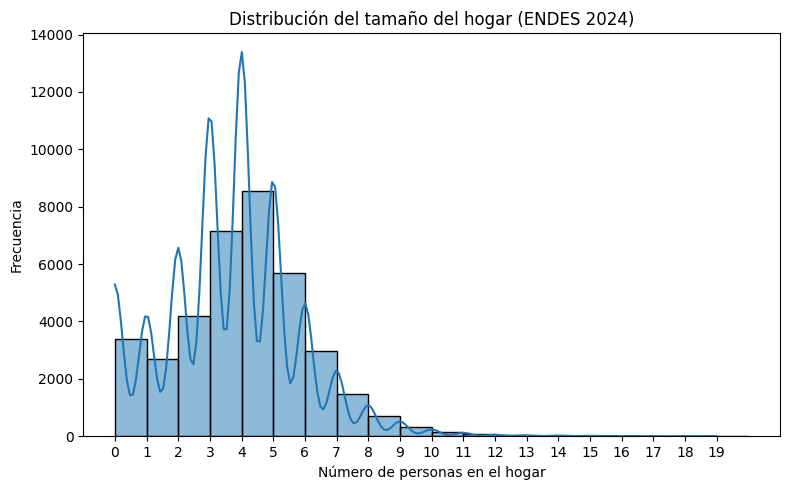

In [36]:
import numpy as np

plt.figure(figsize=(8, 5))

sns.histplot(
    data=rech0,
    x="HV009",
    bins=range(int(rech0["HV009"].min()), int(rech0["HV009"].max()) + 2),
    kde=True # mejor quitar KDE para variable discreta
)

plt.xticks(np.arange(
    int(rech0["HV009"].min()),
    int(rech0["HV009"].max()) + 1,
    1
))

plt.title("Distribución del tamaño del hogar (ENDES 2024)")
plt.xlabel("Número de personas en el hogar")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

_Conclusión: De acuerdo al histograma, observamos una campana asimétrica con cola a la derecha, se observa que la distribución del tamaño del hogar está concentrado entre 3 y 5 personas por hogar, siendo menos frecuente que haya una gran cantidad de personas en un solo hogar (más de 8)_

# Gráfico de pastel

In [44]:
# Haremos un gráfico de pue para ver la proporción de niños menores de 5 años en zonas urbanas y rurales
# HV025 (urbano/rural)  +  "HV014",      # Niños <5

# agrupar cantidad de HV014 por HV025
niños_urbano_rural = (
    rech0.groupby("HV025", as_index=False)["HV014"]
    .sum()
    .rename(columns={"HV014": "total_niños_menores_de_5_años"})
)

C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13208\3135431100.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rech0.groupby("HV025", as_index=False)["HV014"]


In [45]:
niños_urbano_rural

,HV025,total_niños_menores_de_5_años
0,1,17724
1,2,7349


In [46]:
# renombraremos 1 como urbano y 2 como rural
map = {1: "Urbano", 2: "Rural"}
niños_urbano_rural["HV025"] = niños_urbano_rural["HV025"].astype(int).map(map)
niños_urbano_rural



,HV025,total_niños_menores_de_5_años
0,Urbano,17724
1,Rural,7349


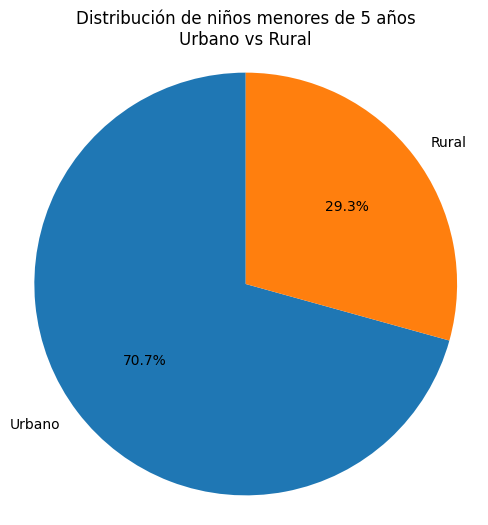

In [47]:
# Ahora que tenemos nuestro dataframe listo podemos pasar a graficar
plt.figure(figsize=(6, 6))

plt.pie(
    niños_urbano_rural["total_niños_menores_de_5_años"],
    labels=niños_urbano_rural["HV025"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de niños menores de 5 años\nUrbano vs Rural")
plt.axis("equal")  # para que sea círculo perfecto

plt.show()

_Comentario: Se observa una mayor concentración de niños menores de 5 años en el ámbito urbano en comparación con el ámbito rural_

# TREEMAP

In [53]:
# Haremos un gráfico treemap HV024 por cada región contar los miembros residentes habituales HV012
# primero el dataseet

residentes_por_region = (
    rech0.groupby("region", as_index=False)["HV012"]
    .sum()
    .rename(columns={"HV012": "residentes_habituales"})
    .sort_values("residentes_habituales", ascending=False)
)

residentes_por_region

,region,residentes_habituales
14,Lima,16692
15,Loreto,5936
24,Ucayali,5473
19,Piura,5397
4,Ayacucho,5322
9,Huanuco,5283
12,La Libertad,5281
0,Amazonas,5279
10,Ica,5259
13,Lambayeque,5188


In [56]:
# pasamos ahacer el gráfico

fig = px.treemap(
    residentes_por_region,
    path=["region"],
    values="residentes_habituales",
    title="Miembros residentes habituales por región - ENDES 2024"
)

fig.show()

c:\Users\JHOSSEP\anaconda3\envs\mi_entorno310\lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




_Conclusión: El gráfico evidencia alta predominancia de residentes en Lima a comparación de las otras regiones_

# BOX PLOT

C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13208\3589057923.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




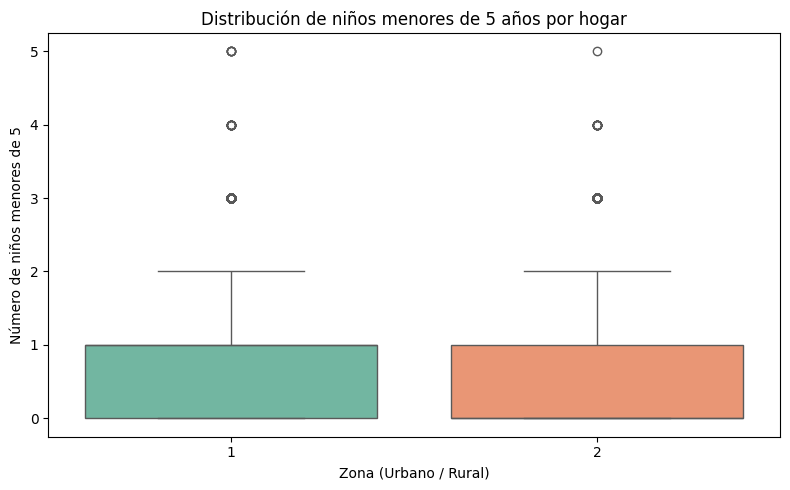

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rech0,
    x="HV025",
    y="HV014",  # niños menores de 5 por hogar
    palette="Set2"
)

plt.title("Distribución de niños menores de 5 años por hogar")
plt.xlabel("Zona (Urbano / Rural)")
plt.ylabel("Número de niños menores de 5")
plt.tight_layout()

plt.show()

_Conclusión: La distribución de niños menores de 5 años por gofar es similar en zonas rurales y urbanas, concentrándose los datos entre 0 o 1 niño, en su mayoría tienen 0 niños, con algunos casos excepcionales_

# Gráfico de violin

C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13208\323213667.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




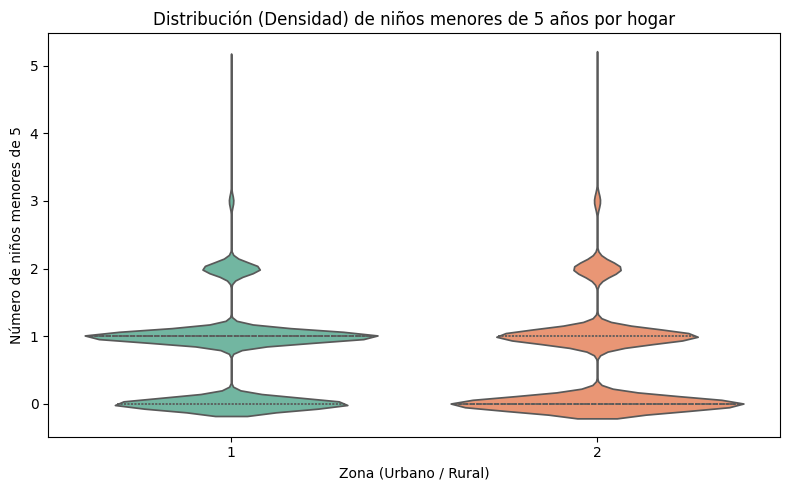

In [61]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=rech0,
    x="HV025",
    y="HV014", 
    palette="Set2",
    inner="quartile"  # Esto añade las líneas de los cuartiles dentro del violín
)

plt.title("Distribución (Densidad) de niños menores de 5 años por hogar")
plt.xlabel("Zona (Urbano / Rural)")
plt.ylabel("Número de niños menores de 5")
plt.tight_layout()

plt.show()

_COnclusión: La mayoría de personas tanto en zonas rurales como urbanas tienen hijos menore de 5 años en cantidades de 0 a 1, hay unos pocos casos en los que tienen más cantidad de hijos menores de 5 años, gracias a este gráfico podemos ver la distribución_

# Sunburst Chart

In [63]:
# CELDA 1: Crear pseudo data para Sunburst Chart

import pandas as pd
import numpy as np

# Fijamos semilla para que los resultados sean reproducibles
np.random.seed(42)

# Creamos categorías jerárquicas
zonas = ["Urbano", "Rural"]

regiones = {
    "Urbano": ["Lima", "Arequipa", "La Libertad", "Piura"],
    "Rural": ["Cajamarca", "Puno", "Ayacucho", "Huancavelica"]
}

servicios = ["Agua potable", "Electricidad", "Internet", "Saneamiento"]

# Generamos la pseudo base
data = []

for zona in zonas:
    for region in regiones[zona]:
        for servicio in servicios:
            hogares = np.random.randint(100, 1500)
            data.append([zona, region, servicio, hogares])

sunburst_data = pd.DataFrame(
    data,
    columns=["zona", "region", "servicio", "hogares"]
)

sunburst_data.head()

,zona,region,servicio,hogares
0,Urbano,Lima,Agua potable,1226
1,Urbano,Lima,Electricidad,960
2,Urbano,Lima,Internet,1394
3,Urbano,Lima,Saneamiento,1230
4,Urbano,Arequipa,Agua potable,1195


In [64]:
# CELDA 2: Crear Sunburst Chart

import plotly.express as px

fig = px.sunburst(
    sunburst_data,
    path=["zona", "region", "servicio"],  # Jerarquía del gráfico
    values="hogares",                     # Tamaño de cada sección
    title="Distribución simulada de hogares por zona, región y servicio"
)

fig.show()

_Comentario: De la data creada, podemos ver que la mayoría de hogares pertenecen a la zona urbana, y dentro de la zona urbana por ejemplo LA LIBERTAD cuenta en su gran mayoría con saneamiento y agua potable, pero pocos hogares cuentan con Electricidad e internet_

# Scatter Plot

In [66]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 400

# Altitud (continua)
altitud = np.random.normal(1500, 800, n)

# Ingreso mensual (continuo, inversamente relacionado con altitud)
ingreso = 3000 - altitud * 0.5 + np.random.normal(0, 500, n)

# Asegurar valores positivos
ingreso = np.clip(ingreso, 200, None)

# Zona
zona = np.where(altitud > 1500, "Rural", "Urbano")

df_sim = pd.DataFrame({
    "altitud": altitud,
    "ingreso": ingreso,
    "zona": zona
})

df_sim.head()

,altitud,ingreso,zona
0,1897.371322,1254.100509,Rural
1,1389.388559,2005.618209,Urbano
2,2018.150830,1993.546435,Rural
3,2718.423885,1664.278354,Rural
4,1312.677300,2118.628614,Urbano


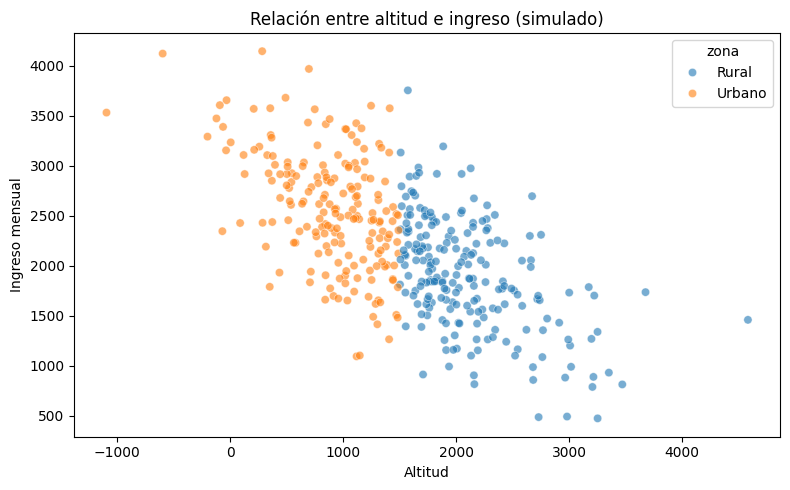

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_sim,
    x="altitud",
    y="ingreso",
    hue="zona",
    alpha=0.6
)

plt.title("Relación entre altitud e ingreso (simulado)")
plt.xlabel("Altitud")
plt.ylabel("Ingreso mensual")

plt.tight_layout()
plt.show()

_Conclusión: Mayores niveles de altitud, se asocian con menores ingresos. Podemos decir que hay una relación inversa en la altitud y el ingreso mensual. Las zonas rurales albergan mayor altitud en comparación con zonas urbanas._

In [ ]:
# uniremos por ubigeo
rech0_dist = (
    rech0.groupby("UBIGEO").apply(lambda x: pd.Series({
        "ID1": 2024,
        "n_hogares_muestra": x["HHID"].count(),
        "hogares_ponderados": x["HV005"].sum(),
        "promedio_personas_hogar": (x["HV009"] * x["HV005"]).sum() / x["HV005"].sum(),
        "proporcion_hogares_rurales": ((x["HV025"] == 2) * x["HV005"]).sum() / x["HV005"].sum(),
        "proporcion_hogares_con_ninos_menores_5": ((x["HV014"] > 0) * x["HV005"]).sum() / x["HV005"].sum()
    }))
    .reset_index()
)

C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_13088\1914414122.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rech0.groupby("UBIGEO").apply(lambda x: pd.Series({


In [ ]:
rech0_dist

,UBIGEO,ID1,n_hogares_muestra,hogares_ponderados,promedio_personas_hogar,proporcion_hogares_rurales,proporcion_hogares_con_ninos_menores_5
0,010101,2024.0,141.0,32949454.0,3.467306,0.0,0.270722
1,010103,2024.0,15.0,5375984.0,2.987279,0.0,0.368916
2,010104,2024.0,15.0,3985760.0,3.591590,0.0,0.248848
3,010109,2024.0,15.0,3421492.0,3.442839,0.0,0.283292
4,010112,2024.0,15.0,3296214.0,2.539169,0.0,0.342741
...,...,...,...,...,...,...,...
920,250301,2024.0,111.0,46015830.0,3.701278,0.0,0.390925
921,250302,2024.0,35.0,13841942.0,3.529395,0.0,0.459384
922,250303,2024.0,15.0,6288856.0,4.661157,0.0,0.548209
923,250305,2024.0,25.0,11511454.0,4.181307,0.0,0.435935


In [ ]:
rech0_dist.isnull().sum()

UBIGEO                                    0
ID1                                       0
n_hogares_muestra                         0
hogares_ponderados                        0
promedio_personas_hogar                   0
proporcion_hogares_rurales                0
proporcion_hogares_con_ninos_menores_5    0
dtype: int64

In [ ]:
rech0_dist.describe()

,ID1,n_hogares_muestra,hogares_ponderados,promedio_personas_hogar,proporcion_hogares_rurales,proporcion_hogares_con_ninos_menores_5
count,925.0,925.000000,9.250000e+02,925.000000,925.0,925.000000
mean,2024.0,40.421622,3.677622e+07,3.302969,0.0,0.290545
std,0.0,64.137346,8.621039e+07,0.625868,0.0,0.132147
min,2024.0,10.000000,1.304622e+06,1.331039,0.0,0.000000
25%,2024.0,15.000000,8.219112e+06,2.890119,0.0,0.204366
50%,2024.0,20.000000,1.437744e+07,3.293723,0.0,0.278066
75%,2024.0,40.000000,2.994194e+07,3.659864,0.0,0.361622
max,2024.0,777.000000,1.313308e+09,6.105340,0.0,1.000000


In [ ]:
#renombremos rech0_dist como df
df = rech0_dist.copy()


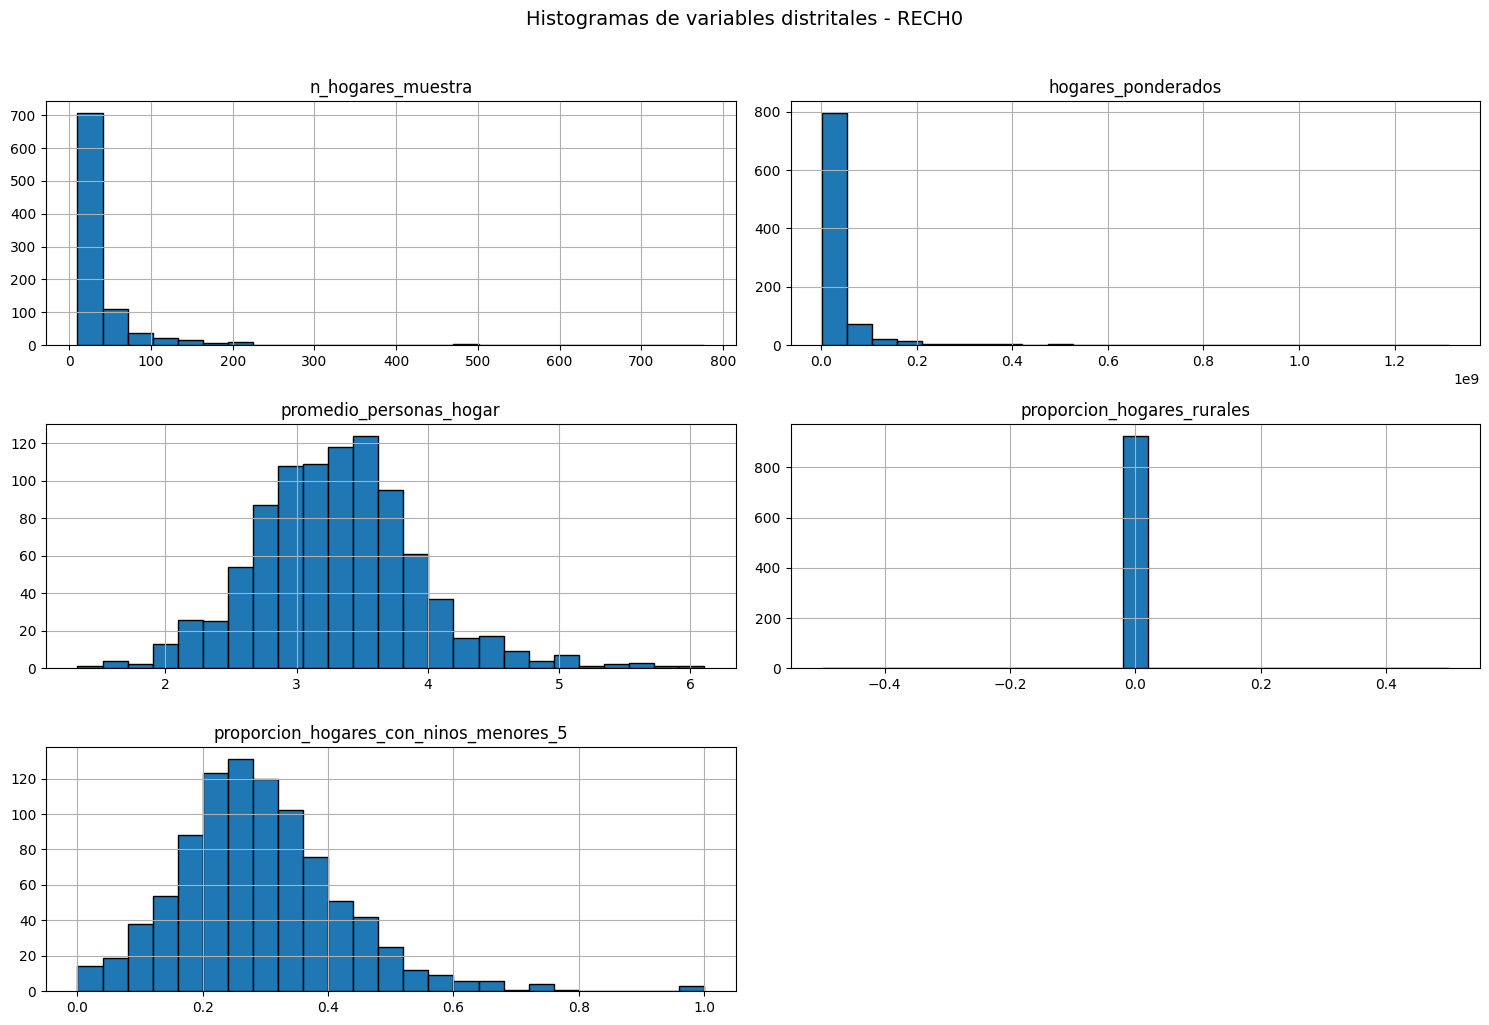

In [ ]:
# las variables numéricas que queremos graficar

vars_num = [
    "n_hogares_muestra",
    "hogares_ponderados",
    "promedio_personas_hogar",
    "proporcion_hogares_rurales",
    "proporcion_hogares_con_ninos_menores_5"
]

df[vars_num].hist(bins=25, figsize=(15,10), edgecolor="black")
plt.suptitle("Histogramas de variables distritales - RECH0", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

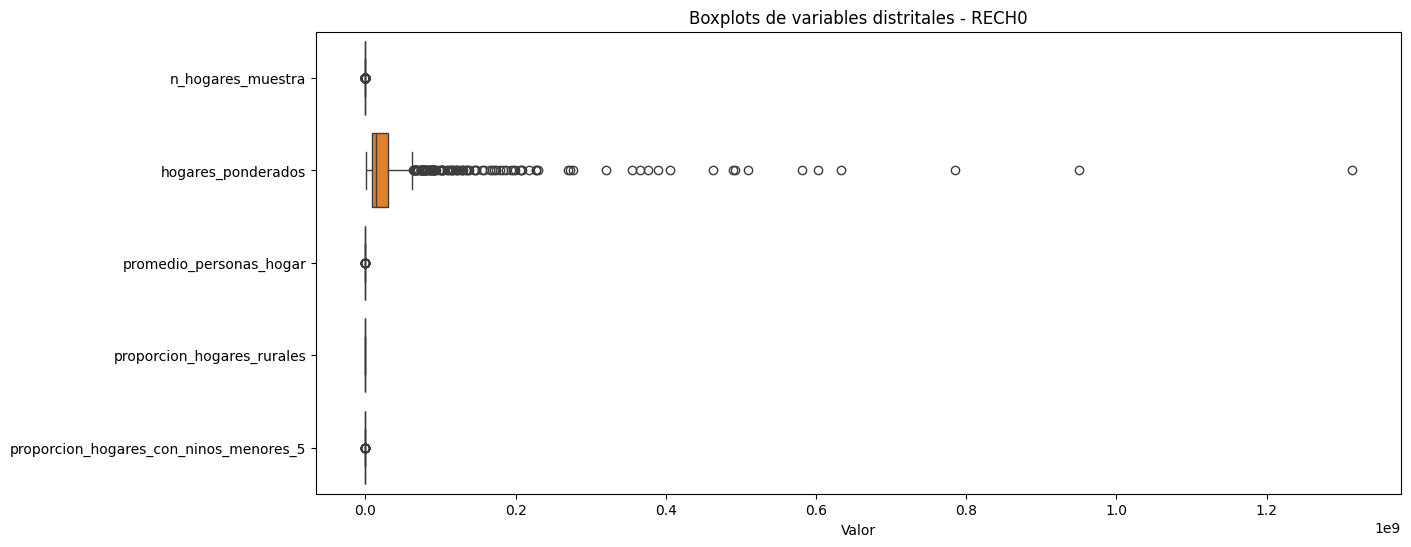

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[vars_num], orient="h")
plt.title("Boxplots de variables distritales - RECH0")
plt.xlabel("Valor")
plt.show()

In [ ]:
rech0_dist

,UBIGEO,ID1,n_hogares_muestra,hogares_ponderados,promedio_personas_hogar,proporcion_hogares_rurales,proporcion_hogares_con_ninos_menores_5
0,010101,2024.0,141.0,32949454.0,3.467306,0.0,0.270722
1,010103,2024.0,15.0,5375984.0,2.987279,0.0,0.368916
2,010104,2024.0,15.0,3985760.0,3.591590,0.0,0.248848
3,010109,2024.0,15.0,3421492.0,3.442839,0.0,0.283292
4,010112,2024.0,15.0,3296214.0,2.539169,0.0,0.342741
...,...,...,...,...,...,...,...
920,250301,2024.0,111.0,46015830.0,3.701278,0.0,0.390925
921,250302,2024.0,35.0,13841942.0,3.529395,0.0,0.459384
922,250303,2024.0,15.0,6288856.0,4.661157,0.0,0.548209
923,250305,2024.0,25.0,11511454.0,4.181307,0.0,0.435935


### Cargamos el shapefile

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

ruta_shp = "../data/DISTRITOS_LIMITES/DISTRITOS.shp"

mapa = gpd.read_file(ruta_shp)

In [ ]:
mapa.head()


,OBJECTID_1,UBIGEO,CODDEP,DEPARTAMEN,CODPROV,PROVINCIA,CODDIST,DISTRITO,CAPITAL,FUENTE,geometry
0,1,030220,03,APURIMAC,02,ANDAHUAYLAS,20,JOSE MARIA ARGUEDAS,HUANCABAMBA,INEI,"POLYGON ((-73.37071 -13.70846, -73.36971 -13.7..."
1,2,030415,03,APURIMAC,04,AYMARAES,15,TINTAY,TINTAY,INEI,"POLYGON ((-73.17529 -13.80103, -73.17388 -13.8..."
2,3,030409,03,APURIMAC,04,AYMARAES,09,LUCRE,LUCRE,INEI,"POLYGON ((-73.24364 -13.81554, -73.24288 -13.8..."
3,4,030214,03,APURIMAC,02,ANDAHUAYLAS,14,SAN MIGUEL DE CHACCRAMPA,CHACCRAMPA,INEI,"POLYGON ((-73.63057 -13.90924, -73.62949 -13.9..."
4,5,030206,03,APURIMAC,02,ANDAHUAYLAS,06,HUAYANA,HUAYANA,INEI,"POLYGON ((-73.51096 -13.91122, -73.51029 -13.9..."


In [ ]:
mapa["UBIGEO"] = mapa["UBIGEO"].astype(str).str.zfill(6)

In [ ]:
# hacemos el mergue
mapa_final = mapa.merge(rech0_dist, on="UBIGEO", how="left")

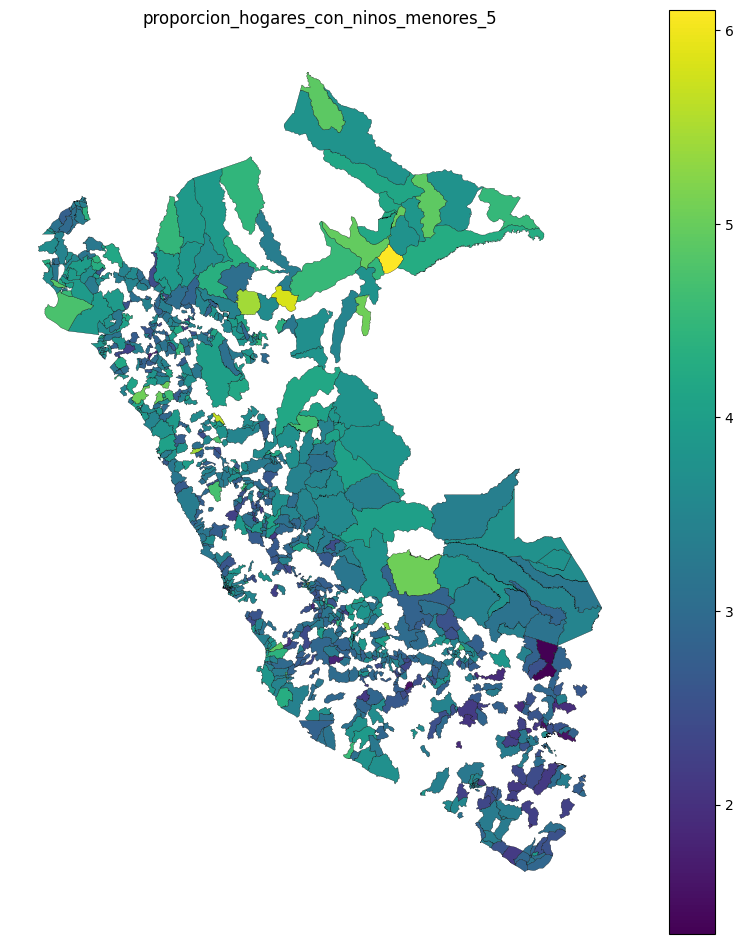

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))

mapa_final.plot(
    column="promedio_personas_hogar",
    cmap="viridis",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("proporcion_hogares_con_ninos_menores_5")
ax.axis("off")
plt.show()